## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
**Regression predicts continuous numerical value outcomes (quantitative values) while classification predicts discrete labels or classes (Categories like Yes/No).** 

2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
**A confusion table/matrix is a table used in machine learning to evaluate classification model performance by comparing predicted classes against actual ground truth, breaking down results into True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).**


3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
**Accuracy is the number of correct predictions over the number of total predictions. It may not be entirely sufficient when classes are imbalanced and different errors have different costs (ex. a false positive is much worse than a false positive).**

4. What does the root mean squared error quantify about a particular model?
**RMSE measures the typical size of a regression model’s prediction errors by seeing on average how far off predictions are from the truth values**


5. What are overfitting and underfitting? 
**Underfitting: model is too simple to capture the real pattern so it does poorly on training and test data due to high bias.**

**Overfitting: model learns noise of the training set so it does well on training but worse on test (high variance).**

6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?

**Splitting the data into training and testing sets allows you to measure how well the model generalizes to new data and avoid overfitting (data memorization). By testing multiple k values on the test set, you can identify the model complexity that minimizes error.**

7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Hard prediction (output a class label):**
**Strengths:**
  - Simple and easy to use/interpret
  - Works well when decisions are binary
**Weaknesses:**
  - Hides uncertainty
  - Harder to tune for different goals

**Soft Prediction (Output probabilities):**
**Strengths:**
  - Gives confidence/uncertainty
  - Let you choose a threshold based on costs
**Weaknesses:**
  - Probabilities can be miscalibrated
  - Requires picking a threshold anyway for final decisions




**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
Shape: (338, 4)
NA counts:
 voltage      0
height       0
soil         0
mine_type    0
dtype: int64
mine_type counts:
 mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000


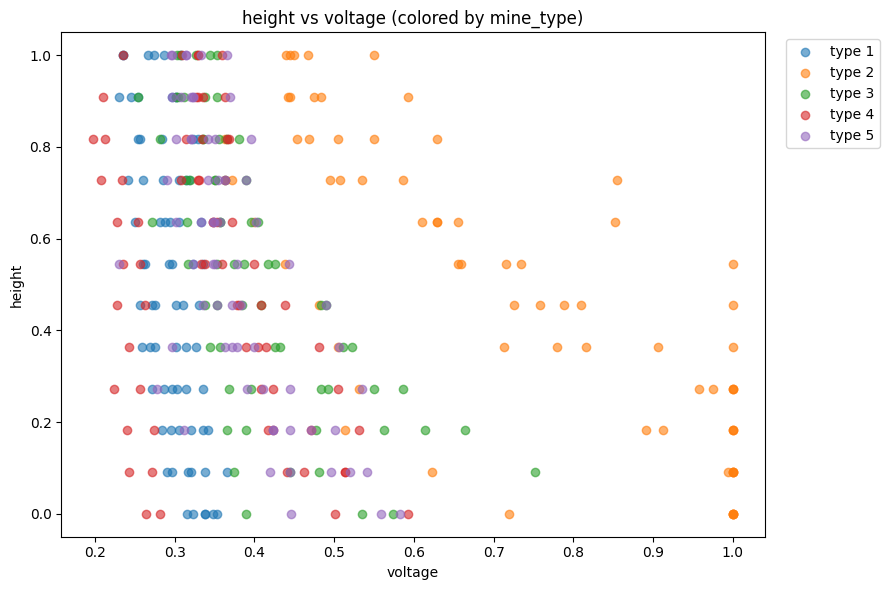

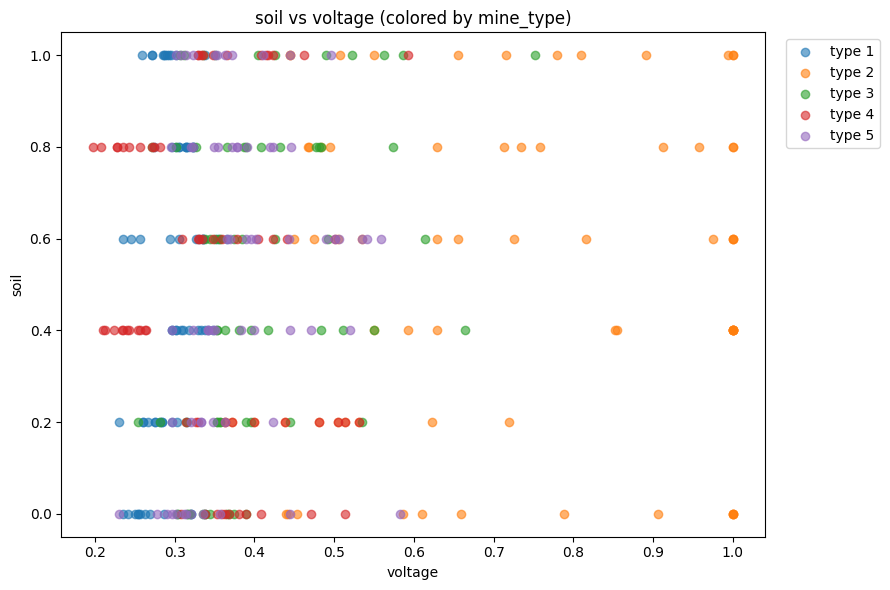

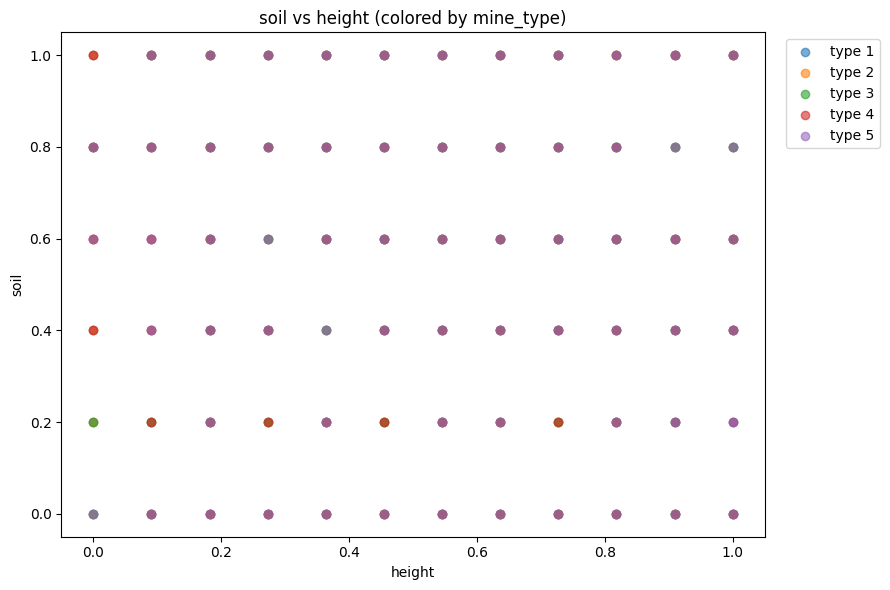

In [71]:
# 2.1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df_mines = pd.read_csv("./data/land_mines.csv")
print(df_mines.head())
print("Shape:", df_mines.shape)
print("NA counts:\n", df_mines.isnull().sum())
print("mine_type counts:\n", df_mines["mine_type"].value_counts().sort_index())
print(df_mines[["voltage","height","soil"]].describe())

# Features + target
x = df_mines.loc[:, ["voltage", "height", "soil"]]
y = df_mines["mine_type"]
# Simple scatterplots (bigger + legend outside)
def scatter_by_class(xcol, ycol):
    plt.figure(figsize=(9, 6))
    for mt in sorted(df_mines["mine_type"].unique()):
        sub = df_mines[df_mines["mine_type"] == mt]
        plt.scatter(sub[xcol], sub[ycol], alpha=0.6, label=f"type {mt}")
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(f"{ycol} vs {xcol} (colored by mine_type)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

scatter_by_class("voltage", "height")
scatter_by_class("voltage", "soil")
scatter_by_class("height", "soil")

In [72]:
# 2.2
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.5, random_state=50, stratify=y
)

scaler = StandardScaler()
u_train = scaler.fit_transform(x_train)
u_test  = scaler.transform(x_test)

k= 3 | test accuracy=0.4201 | train accuracy=0.7041
k= 5 | test accuracy=0.3728 | train accuracy=0.6686
k= 7 | test accuracy=0.3728 | train accuracy=0.6154
k= 9 | test accuracy=0.3609 | train accuracy=0.5976
k=11 | test accuracy=0.3787 | train accuracy=0.5562
k=13 | test accuracy=0.3491 | train accuracy=0.5207
k=15 | test accuracy=0.3432 | train accuracy=0.4911
k=17 | test accuracy=0.3550 | train accuracy=0.4852
k=19 | test accuracy=0.3787 | train accuracy=0.4615
k=21 | test accuracy=0.3550 | train accuracy=0.4438
k=23 | test accuracy=0.3728 | train accuracy=0.4260
k=25 | test accuracy=0.3728 | train accuracy=0.4083
k=27 | test accuracy=0.3787 | train accuracy=0.4438
k=29 | test accuracy=0.3669 | train accuracy=0.4260
k=31 | test accuracy=0.3550 | train accuracy=0.4024
k=33 | test accuracy=0.3254 | train accuracy=0.4260
k=35 | test accuracy=0.3314 | train accuracy=0.3905
k=37 | test accuracy=0.3254 | train accuracy=0.4142
k=39 | test accuracy=0.3195 | train accuracy=0.3787
k=41 | test 

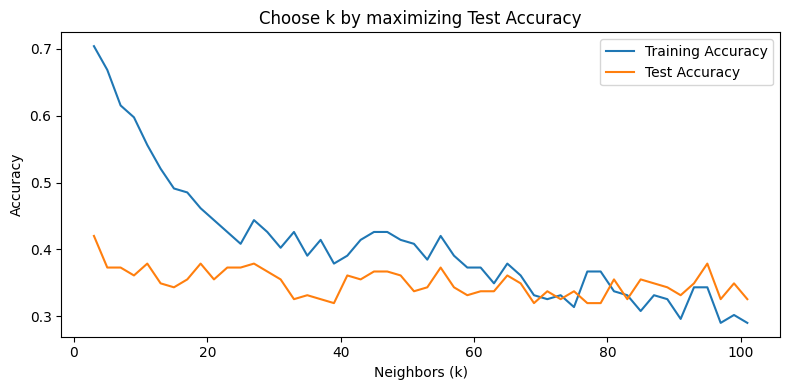


Best k = 3 | Best test accuracy = 0.42011834319526625


In [73]:
# 2.3
k_grid = np.array([(2*k + 3) for k in range(0, 50)])  # 1,3,5,...,51
test_accs = []
train_accs = []

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(u_train, y_train)

    test_acc = model.score(u_test, y_test)
    train_acc = model.score(u_train, y_train)

    print(f"k={k:2d} | test accuracy={test_acc:.4f} | train accuracy={train_acc:.4f}")
    test_accs.append(test_acc)
    train_accs.append(train_acc)

test_accs = np.array(test_accs)
train_accs = np.array(train_accs)

plt.figure(figsize=(8,4))
plt.plot(k_grid, train_accs, label="Training Accuracy")
plt.plot(k_grid, test_accs, label="Test Accuracy")
plt.xlabel("Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Choose k by maximizing Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# "Optimal" k
best_idx = np.argmax(test_accs)
k_opt = int(k_grid[best_idx])
print("\nBest k =", k_opt, "| Best test accuracy =", test_accs[best_idx])

**I selected k using a 50/50 train–test split (stratified so every class appears in both sets). I trained kNN classifiers for a grid of odd k values and chose the k that maximized test-set accuracy. Odd k values reduce tie votes in majority classification.**

In [74]:
# 2.4
model = KNeighborsClassifier(n_neighbors=k)
model.fit(u_train, y_train)          # use scaled train
y_hat = model.predict(u_test)        # use scaled test

print("Accuracy score:", accuracy_score(y_test, y_hat))

# Crosstab confusion table
print("\nCrosstab (Actual rows, Pred cols):")
print(pd.crosstab(y_test, y_hat, rownames=["Actual"], colnames=["Predicted"]))

# Confusion matrix (numpy array)
print("\nConfusion matrix (same as crosstab but as array):")
print(confusion_matrix(y_test, y_hat, labels=sorted(y_train.unique())))

# y_test = actual labels, y_hat = predicted labels
classes = sorted(y_test.unique())  # [1,2,3,4,5]

cm = confusion_matrix(y_test, y_hat, labels=classes)

# recall per class = diagonal / row sum
row_sums = cm.sum(axis=1)
recall = np.diag(cm) / row_sums

recall_df = pd.DataFrame({
    "mine_type": classes,
    "recall": recall
})

print("\nPer-class recall:\n", recall_df)

Accuracy score: 0.3254437869822485

Crosstab (Actual rows, Pred cols):
Predicted  1   2   3  4  5
Actual                    
1          5   0  15  8  8
2          0  19  12  0  4
3          4   2  19  3  5
4          4   0  20  4  5
5          2   1  14  7  8

Confusion matrix (same as crosstab but as array):
[[ 5  0 15  8  8]
 [ 0 19 12  0  4]
 [ 4  2 19  3  5]
 [ 4  0 20  4  5]
 [ 2  1 14  7  8]]

Per-class recall:
    mine_type    recall
0          1  0.138889
1          2  0.542857
2          3  0.575758
3          4  0.121212
4          5  0.250000


**2.4. The overall test accuracy for my best kNN model was 32.5%. From the confusion matrix, performance was higher for mine types 2 and 3 (recall ≈ 54% and 58%, respectively), but very poor for types 1 and 4 (recall ≈ 14% and 12%). The most common mistakes were type 4 being predicted as type 3 (20 cases) and type 1 being predicted as type 3 (15 cases), showing that several classes overlap heavily in the feature space.**

**2.5 In practice, I would advise someone not to automatically make a decision based on the model's output. Instead, I would use it as a decision-support/triage tool: predictions for types 2 and 3 are somewhat more reliable, but for types 1 and 4 which it seems to confuse often, I would use other methods of verification on top of the model.**


**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [75]:
# 3.1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

df_cars = pd.read_csv("./data/USA_cars_datasets.csv")
df_cars = df_cars.loc[:, ['price', 'year', 'mileage']].copy()

print(df_cars.head())
print(df_cars.shape)
print(df_cars.isnull().sum())

X = df_cars[["year", "mileage"]]
y = df_cars["price"]



   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
(2499, 3)
price      0
year       0
mileage    0
dtype: int64


Q3.1

**There are no NA values to deal with!**

In [76]:
# 3.2 and 3.3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50
)

scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


k=  3 | Test MSE = 149,597,499.50 | RMSE = 12,231.01


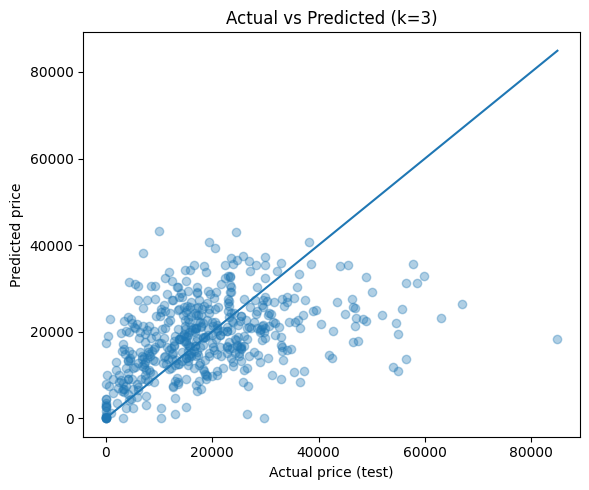

k= 10 | Test MSE = 128,855,771.16 | RMSE = 11,351.47


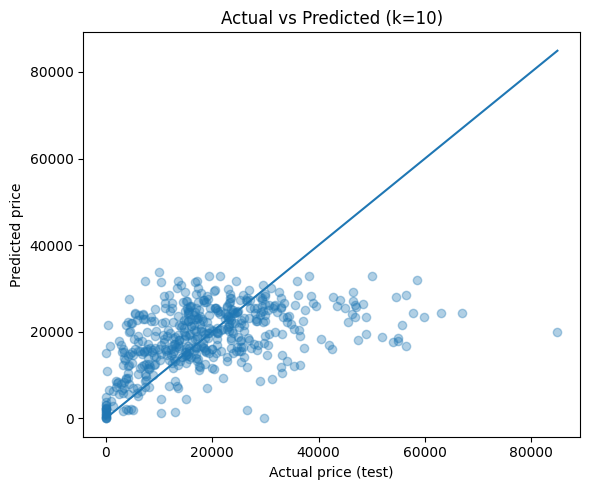

k= 25 | Test MSE = 123,877,519.82 | RMSE = 11,130.03


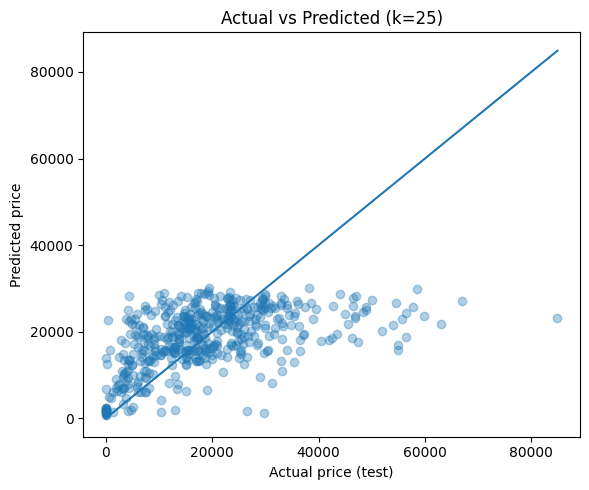

k= 50 | Test MSE = 121,085,407.89 | RMSE = 11,003.88


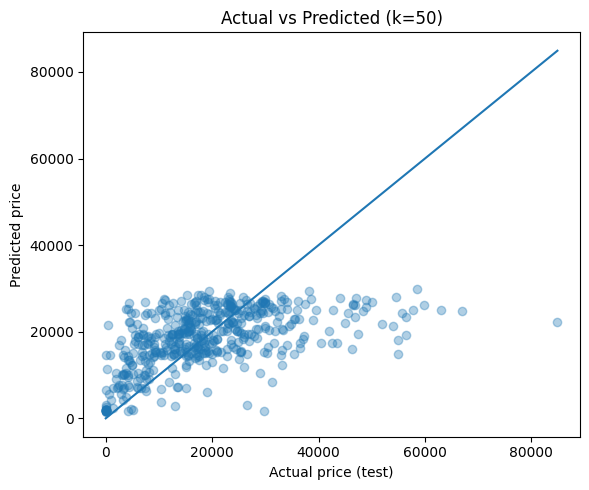

k=100 | Test MSE = 121,335,684.95 | RMSE = 11,015.25


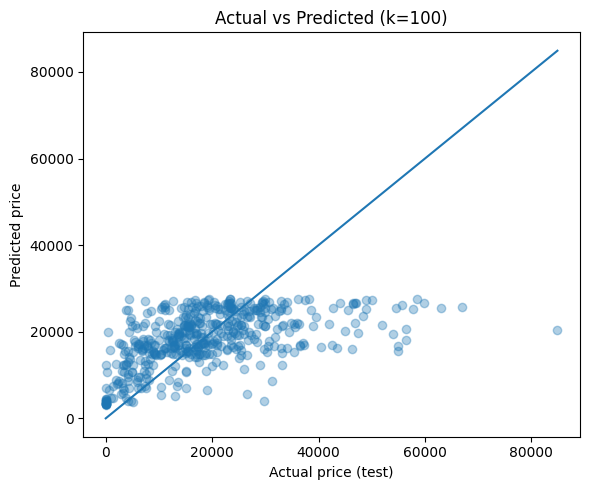

k=300 | Test MSE = 125,954,398.77 | RMSE = 11,222.94


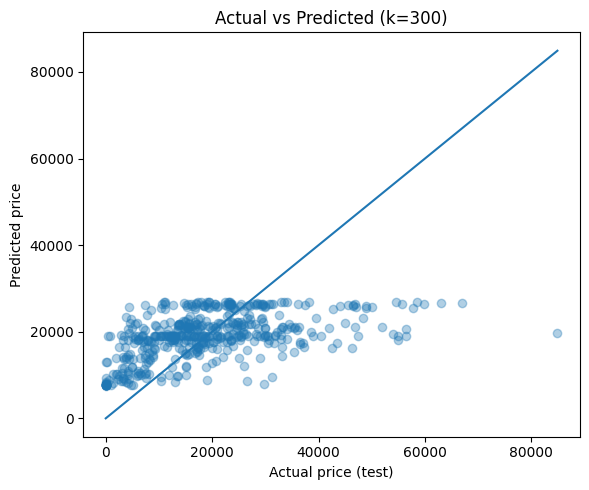


Best k among [3,10,25,50,100,300] =  50 | Min Test MSE = 121085407.89475521


In [77]:
# 3.4
k_list = [3, 10, 25, 50, 100, 300]
mse_by_k = {}

for k in k_list:
    k_use = min(k, len(X_train_s))  
    model = KNeighborsRegressor(n_neighbors=k_use)
    model.fit(X_train_s, y_train)

    y_hat = model.predict(X_test_s)
    mse = mean_squared_error(y_test, y_hat)
    rmse = np.sqrt(mse)
    mse_by_k[k_use] = mse

    print(f"k={k_use:3d} | Test MSE = {mse:,.2f} | RMSE = {rmse:,.2f}")

    # scatterplot actual vs predicted
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_hat, alpha=0.35)
    mn = min(y_test.min(), y_hat.min())
    mx = max(y_test.max(), y_hat.max())
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Actual price (test)")
    plt.ylabel("Predicted price")
    plt.title(f"Actual vs Predicted (k={k_use})")
    plt.tight_layout()
    plt.show()

best_k = min(mse_by_k, key=mse_by_k.get)
print("\nBest k among [3,10,25,50,100,300] = ", best_k, "| Min Test MSE =", mse_by_k[best_k])

**3.5: The optimal k is 50 with a minimum MSE = 121085407.895**

**3.6: For small k, the kNN regressor overfits meaning that predictions vary a lot as each point is determined by only a few neighbors (high variance and more noise). As k increases, the predictions smooth out and become more stable as test MSE decreases. However, as k becomes very large, the kNN regressor underfits meaning that predictions shrink toward an average price and high-priced cars are systematically underpredicted (high bias).**

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [78]:
# 6.1
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt

df_airbnb = pd.read_csv("data/airbnb_hw.csv", encoding="latin1")
df_airbnb = df_airbnb.loc[:, ['Review Scores Rating', 'Price', 'Beds']].copy()

df_airbnb["Price"] = (
    df_airbnb["Price"].astype(str)
      .str.replace(r"[\$,]", "", regex=True)
      .replace("nan", np.nan)
      .astype(float)
)

df_airbnb["Beds"] = pd.to_numeric(df_airbnb["Beds"], errors="coerce")


In [79]:
# 6.2
missing = df_airbnb['Review Scores Rating'].isnull()
df_missing = df_airbnb.loc[missing].copy()
df_complete = df_airbnb.loc[~missing].copy()

In [80]:
# 6.3
df_complete = df_complete.dropna(axis=0, how="any")

Test SSE for k=3: 419042.31; Train SSE for k=3: 1602262.94
Test SSE for k=5: 367157.80; Train SSE for k=5: 1428743.69
Test SSE for k=7: 355557.06; Train SSE for k=7: 1387502.34
Test SSE for k=9: 349120.10; Train SSE for k=9: 1367143.08
Test SSE for k=11: 340465.30; Train SSE for k=11: 1341557.64
Test SSE for k=15: 330837.35; Train SSE for k=15: 1313078.77
Test SSE for k=21: 334315.21; Train SSE for k=21: 1309266.10
Test SSE for k=31: 328413.27; Train SSE for k=31: 1292037.97
Test SSE for k=41: 328501.00; Train SSE for k=41: 1285641.81
Test SSE for k=51: 326841.86; Train SSE for k=51: 1283378.73
Test SSE for k=61: 326863.61; Train SSE for k=61: 1282448.38
Test SSE for k=71: 328289.63; Train SSE for k=71: 1281954.03
Test SSE for k=81: 327992.37; Train SSE for k=81: 1279555.40
Test SSE for k=91: 327196.96; Train SSE for k=91: 1277844.08
Test SSE for k=101: 326516.87; Train SSE for k=101: 1275460.20


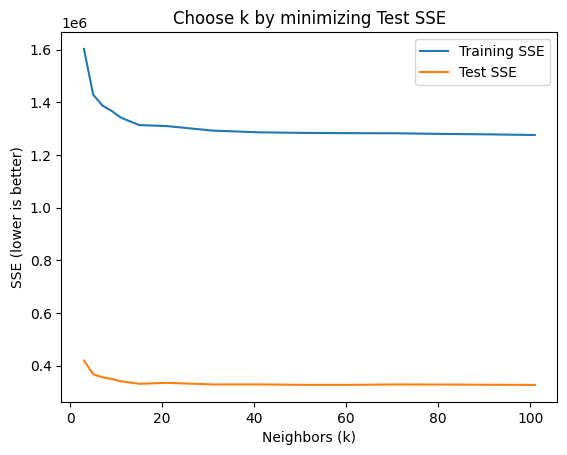

Optimal k = 101 | Min Test SSE = 326516.87185987947


In [81]:
# 6.4

X = df_complete[["Price", "Beds"]].to_numpy(dtype=float)
y = df_complete["Review Scores Rating"].to_numpy(dtype=float)

rng = np.random.default_rng(50)
n = X.shape[0]
idx = np.arange(n)
rng.shuffle(idx)

n_test = int(round(0.2 * n))
test_idx = idx[:n_test]
train_idx = idx[n_test:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

def knn_predict(X_train, y_train, X_query, k):
    eps = 1e-9
    preds = np.empty(X_query.shape[0], dtype=float)
    for i in range(X_query.shape[0]):
        dists = np.sqrt(np.sum((X_train - X_query[i])**2, axis=1))
        nn_idx = np.argpartition(dists, k-1)[:k]
        nn_d = dists[nn_idx]
        nn_y = y_train[nn_idx]
        w = 1.0 / (nn_d + eps)
        preds[i] = np.sum(w * nn_y) / np.sum(w)
    return preds

k_grid = np.array([3,5,7,9,11,15,21,31,41,51,61,71,81,91,101])
test_sse = []
train_sse = []

for k in k_grid:
    yhat_test = knn_predict(X_train, y_train, X_test, k)
    yhat_train = knn_predict(X_train, y_train, X_train, k)

    sse_test = np.sum((y_test - yhat_test)**2)
    sse_train = np.sum((y_train - yhat_train)**2)

    print(f"Test SSE for k={k}: {sse_test:.2f}; Train SSE for k={k}: {sse_train:.2f}")

    test_sse.append(sse_test)
    train_sse.append(sse_train)

test_sse = np.array(test_sse)
train_sse = np.array(train_sse)


plt.figure()
plt.plot(k_grid, train_sse, label="Training SSE")
plt.plot(k_grid, test_sse, label="Test SSE")
plt.xlabel("Neighbors (k)")
plt.ylabel("SSE (lower is better)")
plt.title("Choose k by minimizing Test SSE")
plt.legend()
plt.show()

# Choosing K
optimal_idx = np.argmin(test_sse)
k_optimal = k_grid[optimal_idx]
print("Optimal k =", k_optimal, "| Min Test SSE =", test_sse[optimal_idx])

**The k that minimized the test-set SSE (lowest prediction error on unseen data) is selected as the optimal k which is 101 in this case.**


In [82]:
# 6.5
X_train_full = df_complete[["Price", "Beds"]].to_numpy(dtype=float)
y_train_full = df_complete["Review Scores Rating"].to_numpy(dtype=float)

df_missing_ready = df_missing.dropna(subset=["Price", "Beds"]).copy()
X_missing = df_missing_ready[["Price", "Beds"]].to_numpy(dtype=float)

# Predict missing ratings using the chosen k
y_missing_hat = knn_predict(X_train_full, y_train_full, X_missing, k_optimal)
df_missing_ready["Predicted Review Scores Rating"] = y_missing_hat

print("Predicted", len(df_missing_ready), "missing ratings using k =", k_optimal)


Predicted 8282 missing ratings using k = 101


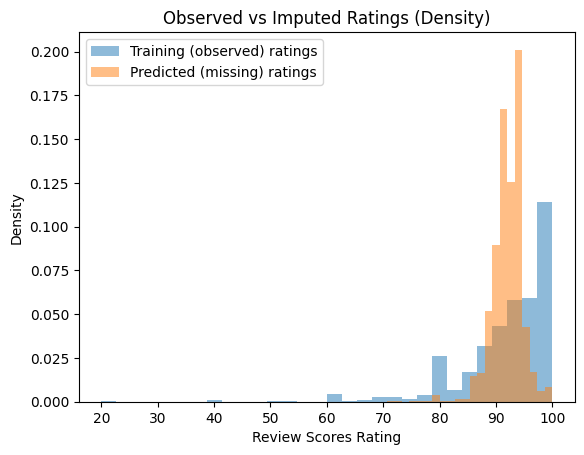

Training mean/std: 91.99163312378454 8.85176455817717
Predicted mean/std: 92.14846808596681 2.7401801019058687


In [83]:
# 6.6

train_ratings = y_train_full
pred_ratings = df_missing_ready["Predicted Review Scores Rating"].to_numpy(dtype=float)

plt.figure()
plt.hist(train_ratings, bins=30, density=True, alpha=0.5, label="Training (observed) ratings")
plt.hist(pred_ratings, bins=30, density=True, alpha=0.5, label="Predicted (missing) ratings")
plt.xlabel("Review Scores Rating")
plt.ylabel("Density")
plt.title("Observed vs Imputed Ratings (Density)")
plt.legend()
plt.show()

print("Training mean/std:", np.mean(train_ratings), np.std(train_ratings))
print("Predicted mean/std:", np.mean(pred_ratings), np.std(pred_ratings))



**6.6 explanation: The predicted (missing) ratings distribution is in the same broad high-rating region as the observed ratings, but it is noticeably narrower and centered a bit lower. The training (observed) ratings have a wider spread and a long left tail with a large range including very low ratings, while the imputed ratings rarely take extreme low values. This makes sense because kNN regression predicts by averaging nearby observations, which smooths predictions toward typical values.**